## Creates the **Grid File** of a specific region by converting the available shapefile into mutliple (X,Y) coordinate pairs to represent each LAU1 Unit ##

In [1]:
import pandas as pd

import random
import geopandas as gpd
import numpy as np

import sys

sys.path.insert(0, "../../../Modules")

from utils import process_greek, create_grid

enc = 'utf-8'
dec = 'greek8'
random.seed(0)
np.random.seed(0)

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\geopandas\_compat.py:112: UserWarning: The Shapely GEOS version (3.10.3-CAPI-1.16.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(


In [2]:
NUTS0 = 'GR'
NUTS2 = 'CMacedonia'
NUTS2_EL = 'κεντρικης μακεδονιας'

In [3]:
## Reading shapefiles from Greece
folder_path = "C:/Users/dimit/Documents/noa hoard/Greece Shapefiles"

greece_gdf = gpd.read_file(f"{folder_path}/elladitsa.shp",  encoding=enc)
greece_regions_gdf = gpd.read_file(f"{folder_path}/perifereies2.shp",  encoding=enc)
rivers_gdf = gpd.read_file(f"{folder_path}/potamoi2.shp", encoding=enc)

In [4]:
greece_gdf.head(5)

,NAME,KWD_YPES,geometry
0,Αμυνταίου,9070,"POLYGON ((21.70746 40.85172, 21.70955 40.85119..."
1,Άθως,None,"MULTIPOLYGON (((24.25167 40.30363, 24.25149 40..."
2,Άκτιου - Βόνιτσας,9124,"MULTIPOLYGON (((20.79456 38.75371, 20.79456 38..."
3,Άνδρου,9268,"MULTIPOLYGON (((24.95917 37.69039, 24.95897 37..."
4,Άργους - Μυκηνών,9233,"POLYGON ((22.52084 37.83857, 22.52111 37.83829..."


In [5]:
greece_regions_gdf.head()

,PER,geometry
0,Π. ΑΝΑΤΟΛΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ - ΘΡΑΚΗΣ,"MULTIPOLYGON (((23.62358 41.35455, 23.62361 41..."
1,Π. ΚΕΝΤΡΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ,"MULTIPOLYGON (((21.70423 40.86339, 21.70425 40..."
2,Π. ΔΥΤΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ,"POLYGON ((20.77648 40.35294, 20.77652 40.35548..."
3,Π. ΗΠΕΙΡΟΥ,"MULTIPOLYGON (((20.00882 39.69130, 20.00884 39..."
4,Π. ΘΕΣΣΑΛΙΑΣ,"MULTIPOLYGON (((21.12042 39.67888, 21.12044 39..."


In [6]:
#choose the correct region

nuts2_gdf = greece_regions_gdf.loc[greece_regions_gdf['PER'] == 'Π. ΚΕΝΤΡΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ']
nuts2_gdf.head()

,PER,geometry
1,Π. ΚΕΝΤΡΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ,"MULTIPOLYGON (((21.70423 40.86339, 21.70425 40..."


In [7]:
indexes = []

nuts2 = nuts2_gdf

for index, row in greece_gdf.iterrows():
    for index2, row2 in nuts2.iterrows():
                    
        if row['geometry'].intersects(row2['geometry']):
                indexes.append(index)

nuts2_gdf = greece_gdf.loc[indexes].reset_index(drop=True)

In [8]:
nuts2_gdf.head()

,NAME,KWD_YPES,geometry
0,Αμυνταίου,9070,"POLYGON ((21.70746 40.85172, 21.70955 40.85119..."
1,Άθως,None,"MULTIPOLYGON (((24.25167 40.30363, 24.25149 40..."
2,Έδεσσας,9043,"POLYGON ((21.99535 40.90380, 21.99562 40.90344..."
3,Αλεξάνδρειας,9023,"MULTIPOLYGON (((22.66199 40.52431, 22.66194 40..."
4,Αλμωπίας,9042,"POLYGON ((22.22498 41.16444, 22.22529 41.16444..."


<AxesSubplot:>

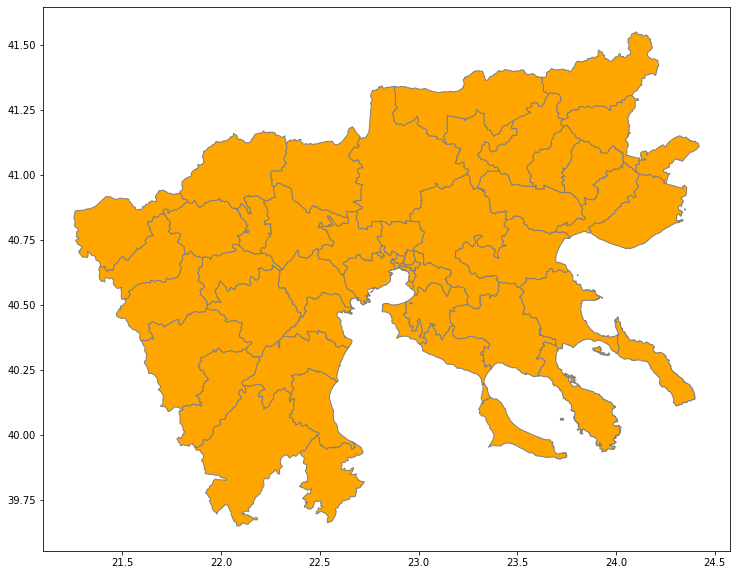

In [9]:
nuts2_gdf.plot(facecolor="none", edgecolor='grey', figsize=(15, 10), color='orange')

In [10]:
#check QGIS for wrong lau1 units

In [11]:
wrong_list = ['Φλώρινας' ,'Αμυνταίου', 'Εορδαίας', 'Κοζάνης', 'Σερβίων - Βελβεντού', 'Ελασσόνας', 'Τεμπών', 'Κάτω Νευροκοπίου',
 'Προσοτσάνης', 'Δοξάτου', 'Παγγαίου', 'Άθως']

nuts2_gdf = nuts2_gdf[~nuts2_gdf['NAME'].isin(wrong_list)].copy()

In [12]:
nuts2_gdf.head(5)

,NAME,KWD_YPES,geometry
2,Έδεσσας,9043,"POLYGON ((21.99535 40.90380, 21.99562 40.90344..."
3,Αλεξάνδρειας,9023,"MULTIPOLYGON (((22.66199 40.52431, 22.66194 40..."
4,Αλμωπίας,9042,"POLYGON ((22.22498 41.16444, 22.22529 41.16444..."
5,Αμπελοκήπων - Μενεμένης,9026,"POLYGON ((22.87764 40.66601, 22.87775 40.66573..."
6,Αμφίπολης,9049,"POLYGON ((24.04143 41.04942, 24.04322 41.04930..."


In [13]:
nuts2_gdf.drop(columns=['KWD_YPES'], inplace = True)
nuts2_gdf.rename(columns={"NAME": "lau1"}, inplace = True)
process_greek(nuts2_gdf, 'lau1')

In [14]:
nuts2_gdf.head(5)

,lau1,geometry
2,εδεσσας,"POLYGON ((21.99535 40.90380, 21.99562 40.90344..."
3,αλεξανδρειας,"MULTIPOLYGON (((22.66199 40.52431, 22.66194 40..."
4,αλμωπιας,"POLYGON ((22.22498 41.16444, 22.22529 41.16444..."
5,αμπελοκηπων μενεμενης,"POLYGON ((22.87764 40.66601, 22.87775 40.66573..."
6,αμφιπολης,"POLYGON ((24.04143 41.04942, 24.04322 41.04930..."


<AxesSubplot:>

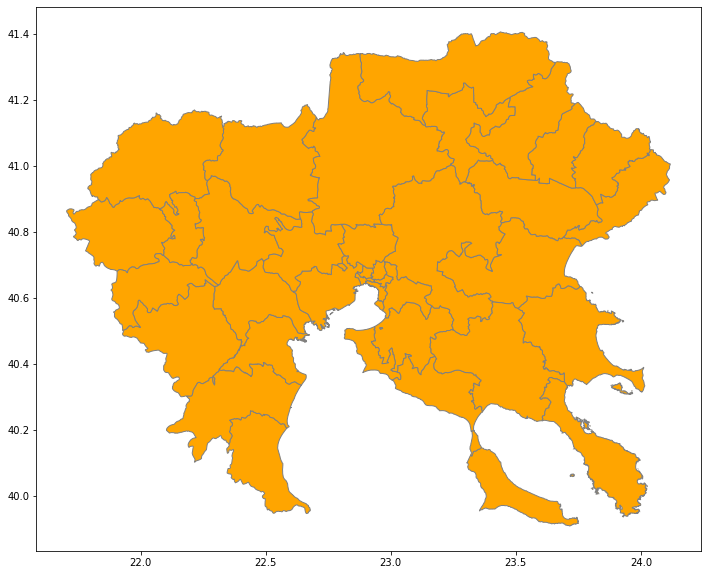

In [15]:
nuts2_gdf.plot(facecolor="none", edgecolor='grey', figsize=(15, 10), color='orange')

In [16]:
indexes = []

nuts2 = nuts2_gdf

for index, row in rivers_gdf.iterrows():
    for index2, row2 in nuts2.iterrows():
                    
        if row['geometry'].intersects(row2['geometry']):
                indexes.append(index)

nuts2_rivers_gdf = rivers_gdf.loc[indexes].reset_index(drop=True)

In [17]:
nuts2_rivers_gdf.head()

,objectid,eu_cd,name,altname1,altname2,altname3,region_cd,system,ins_when,ins_by,...,acid_neut,substratum,chloride,a_temp_rge,av_a_temp,ppt,dist_sourc,cont,shape_Leng,geometry
0,21,GR0009000400010100H,None,None,None,None,None,None,None,None,...,None,None,None,None,0.0,0.0,0.0,yes,17199.809546,"LINESTRING (21.73202 40.68216, 21.79637 40.773..."
1,224,GR001100040B230110N,ÓÔÑÕÌÙÍ Ð. 1,STRYMON R. 1,None,None,None,None,None,None,...,None,None,None,None,0.0,0.0,0.0,no,14069.595949,"LINESTRING (23.80988 40.90157, 23.80988 40.901..."
2,224,GR001100040B230110N,ÓÔÑÕÌÙÍ Ð. 1,STRYMON R. 1,None,None,None,None,None,None,...,None,None,None,None,0.0,0.0,0.0,no,14069.595949,"LINESTRING (23.80988 40.90157, 23.80988 40.901..."
3,224,GR001100040B230110N,ÓÔÑÕÌÙÍ Ð. 1,STRYMON R. 1,None,None,None,None,None,None,...,None,None,None,None,0.0,0.0,0.0,no,14069.595949,"LINESTRING (23.80988 40.90157, 23.80988 40.901..."
4,227,GR001100040B230320N,ÁÃÉÙÍ ÁÍÁÑÃÕÑÙÍ Ñ.,AGION ANARGYRON S.,None,None,None,None,None,None,...,None,None,None,None,0.0,0.0,0.0,no,7703.516408,"LINESTRING (23.54881 41.12369, 23.54925 41.123..."


<AxesSubplot:>

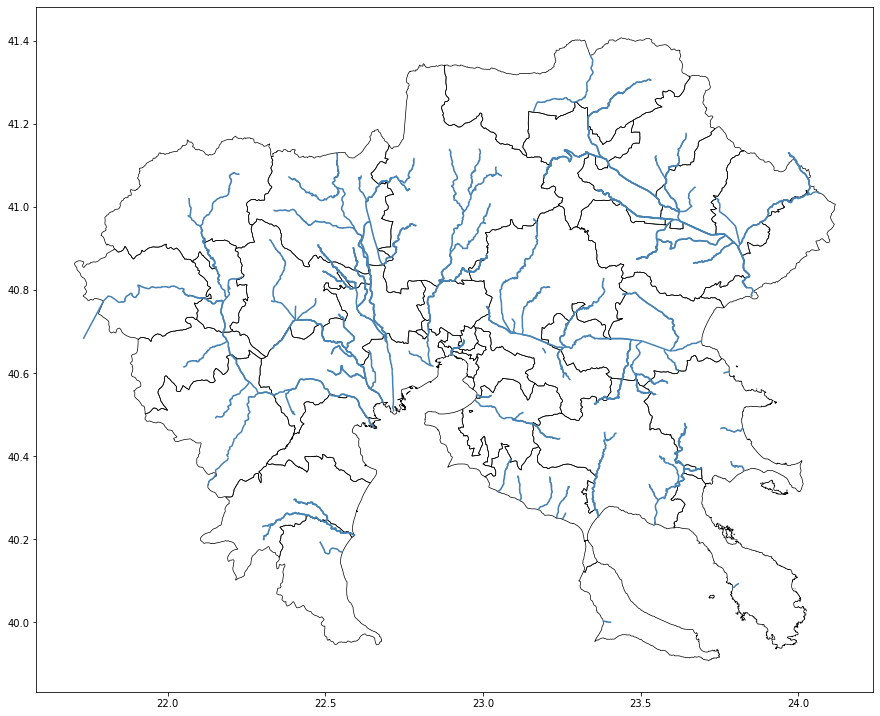

In [18]:
ax = nuts2_rivers_gdf.plot(markersize=.1, figsize=(15, 15), cmap='jet', color='steelblue')
nuts2_gdf.plot(facecolor="none", edgecolor='black', ax=ax, lw=0.7)

In [19]:
lau1_units = nuts2_gdf['lau1'].unique().tolist()

with open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_SHP_LAU1_Units_Processed.txt', 'w', encoding=enc) as f:
    for item in lau1_units:
        f.write("%s\n" % item)

print(f"Number of LAU1 Units in {NUTS2} (from shapefile): {len(lau1_units)}")

Number of LAU1 Units in CMacedonia (from shapefile): 38


In [20]:
nuts2_gdf.reset_index(inplace=True, drop = True)
nuts2_rivers_gdf.reset_index(inplace=True, drop=True)

In [21]:
empty_gdf = gpd.GeoDataFrame(columns=['geometry'], geometry='geometry', crs='EPSG:4326')

df_grid = create_grid(empty_gdf, nuts2_gdf, col_municipal='lau1', dimension=3.5)
# df_grid_2.to_csv('data/grid_2.csv', index=False)
# # df_grid_2 = pd.read_csv('data/grid_2.csv')
# # df_grid_2['geometry'] = gpd.GeoSeries.from_wkt(df_grid_2['geometry'])
# # df_grid_2 = gpd.GeoDataFrame(df_grid_2, geometry='geometry')

e:\Drive\NOA\MBD-Prediction\Greece\notebooks\CMacedonia\../../../Modules\utils.py:735: FutureWarning: Currently, index_parts defaults to True, but in the future, it will default to False to be consistent with Pandas. Use `index_parts=True` to keep the current behavior and True/False to silence the warning.
  river_shapes_list =  river_shapes[col_geometry].geometry.explode().tolist()
c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\pyproj\crs\crs.py:141: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\dtypes\cast.py:118: ShapelyDeprecationWarning: The array interface is deprecated and will no longer work in Sha

In [22]:
df_grid.rename(columns={"NAME": "lau1"}, inplace = True)

<AxesSubplot:>

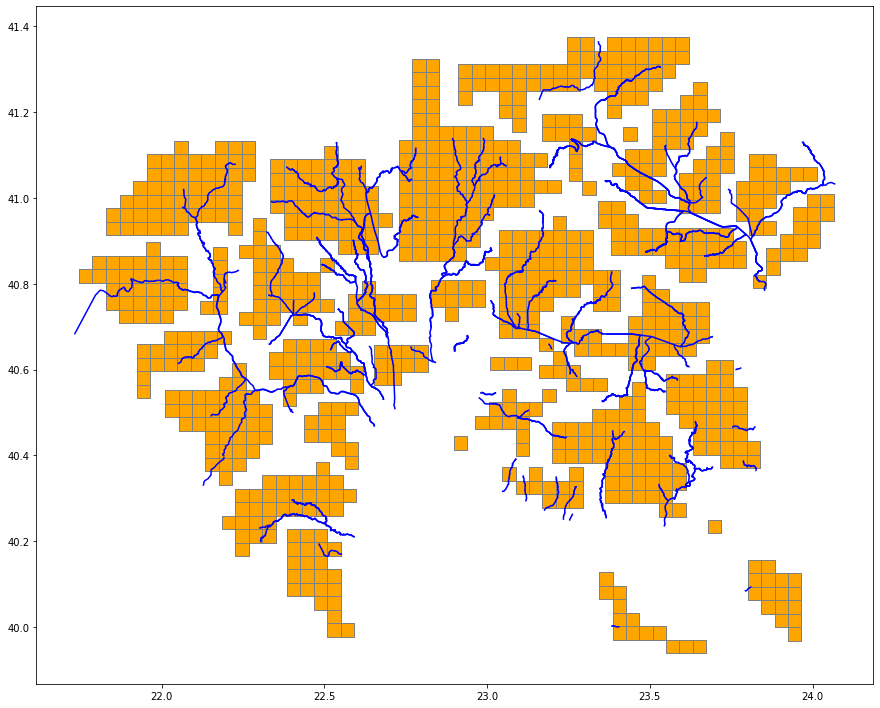

In [23]:
ax = nuts2_rivers_gdf.plot(markersize=.1, figsize=(15, 15), cmap='jet', color='blue')
df_grid.plot(facecolor="none", edgecolor='grey', ax=ax, color='orange')

In [24]:
grid_lau1 = df_grid['lau1'].unique().tolist()
print(f"Number of LAU1 Units in Grid: {len(grid_lau1)}")

Number of LAU1 Units in Grid: 32


['αμπελοκηπων μενεμενης', 'θεσσαλονικης', 'καλαμαριας', 'κορδελιου ευοσμου', 'νεαπολης συκεων', 'παυλου μελα']


C:\Users\dimit\AppData\Local\Temp/ipykernel_12656/839959091.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  lost_lau1["centroid"] = lost_lau1["geometry"].centroid
c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\geopandas\geodataframe.py:1472: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


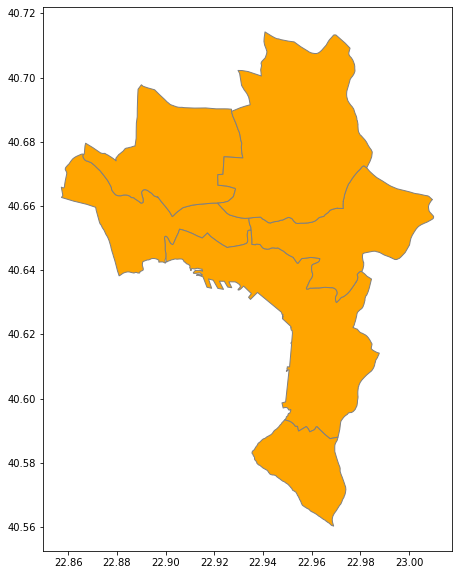

In [25]:
if (len(lau1_units) != len(grid_lau1)):
    delta = [item for item in lau1_units if item not in grid_lau1]
    print(delta)

    lost_lau1 = nuts2_gdf[nuts2_gdf['lau1'].isin(delta)]
    lost_lau1["centroid"] = lost_lau1["geometry"].centroid

    add_to_nuts2_grid = pd.DataFrame()
    add_to_nuts2_grid['lau1'] = lost_lau1['lau1']
    add_to_nuts2_grid['geometry'] = lost_lau1['geometry']
    add_to_nuts2_grid['x'] = round(lost_lau1['centroid'].x, 5)
    add_to_nuts2_grid['y'] = round(lost_lau1['centroid'].y, 5)

    lost_lau1.plot(facecolor="none", edgecolor='grey', figsize=(10, 10), color='orange')

In [26]:
nuts2_grid = df_grid.drop(columns=['centers'])

In [27]:
nuts2_grid

,geometry,lau1,x,y
0,"POLYGON ((21.78711 40.80191, 21.78711 40.83335...",εδεσσας,21.76638,40.81763
1,"POLYGON ((21.82857 40.80191, 21.82857 40.83335...",εδεσσας,21.80784,40.81763
2,"POLYGON ((21.82857 40.83335, 21.82857 40.86479...",εδεσσας,21.80784,40.84907
3,"POLYGON ((21.87003 40.73902, 21.87003 40.77047...",εδεσσας,21.84930,40.75474
4,"POLYGON ((21.87003 40.77047, 21.87003 40.80191...",εδεσσας,21.84930,40.78619
...,...,...,...,...
851,"POLYGON ((22.91111 40.77620, 22.91111 40.80764...",ωραιοκαστρου,22.89038,40.79192
852,"POLYGON ((22.95257 40.74476, 22.95257 40.77620...",ωραιοκαστρου,22.93184,40.76048
853,"POLYGON ((22.95257 40.77620, 22.95257 40.80764...",ωραιοκαστρου,22.93184,40.79192
854,"POLYGON ((22.99403 40.74476, 22.99403 40.77620...",ωραιοκαστρου,22.97330,40.76048


In [28]:
if (len(lau1_units) != len(grid_lau1)):
    nuts2_grid = pd.concat([nuts2_grid, add_to_nuts2_grid], axis=0)

nuts2_grid.reset_index(inplace=True, drop=True)

In [29]:
nuts2_grid['nuts2'] = NUTS2_EL

In [30]:
nuts2_grid.rename(columns={"geometry": "shape"}, inplace=True)

In [31]:
nuts2_grid

,shape,lau1,x,y,nuts2
0,"POLYGON ((21.78711 40.80191, 21.78711 40.83335...",εδεσσας,21.76638,40.81763,κεντρικης μακεδονιας
1,"POLYGON ((21.82857 40.80191, 21.82857 40.83335...",εδεσσας,21.80784,40.81763,κεντρικης μακεδονιας
2,"POLYGON ((21.82857 40.83335, 21.82857 40.86479...",εδεσσας,21.80784,40.84907,κεντρικης μακεδονιας
3,"POLYGON ((21.87003 40.73902, 21.87003 40.77047...",εδεσσας,21.84930,40.75474,κεντρικης μακεδονιας
4,"POLYGON ((21.87003 40.77047, 21.87003 40.80191...",εδεσσας,21.84930,40.78619,κεντρικης μακεδονιας
...,...,...,...,...,...
857,"POLYGON ((22.91314 40.65062, 22.91508 40.65002...",θεσσαλονικης,22.95369,40.62334,κεντρικης μακεδονιας
858,"POLYGON ((22.97084 40.58797, 22.97046 40.58693...",καλαμαριας,22.95724,40.57876,κεντρικης μακεδονιας
859,"POLYGON ((22.90533 40.69077, 22.90624 40.69074...",κορδελιου ευοσμου,22.90326,40.67609,κεντρικης μακεδονιας
860,"POLYGON ((22.99249 40.66620, 22.99532 40.66530...",νεαπολης συκεων,22.97547,40.65206,κεντρικης μακεδονιας


In [32]:
nuts2_grid_points = gpd.GeoDataFrame(nuts2_grid, geometry=gpd.points_from_xy(nuts2_grid.x, nuts2_grid.y))

In [33]:
nuts2_grid_points

,shape,lau1,x,y,nuts2,geometry
0,"POLYGON ((21.78711 40.80191, 21.78711 40.83335...",εδεσσας,21.76638,40.81763,κεντρικης μακεδονιας,POINT (21.76638 40.81763)
1,"POLYGON ((21.82857 40.80191, 21.82857 40.83335...",εδεσσας,21.80784,40.81763,κεντρικης μακεδονιας,POINT (21.80784 40.81763)
2,"POLYGON ((21.82857 40.83335, 21.82857 40.86479...",εδεσσας,21.80784,40.84907,κεντρικης μακεδονιας,POINT (21.80784 40.84907)
3,"POLYGON ((21.87003 40.73902, 21.87003 40.77047...",εδεσσας,21.84930,40.75474,κεντρικης μακεδονιας,POINT (21.84930 40.75474)
4,"POLYGON ((21.87003 40.77047, 21.87003 40.80191...",εδεσσας,21.84930,40.78619,κεντρικης μακεδονιας,POINT (21.84930 40.78619)
...,...,...,...,...,...,...
857,"POLYGON ((22.91314 40.65062, 22.91508 40.65002...",θεσσαλονικης,22.95369,40.62334,κεντρικης μακεδονιας,POINT (22.95369 40.62334)
858,"POLYGON ((22.97084 40.58797, 22.97046 40.58693...",καλαμαριας,22.95724,40.57876,κεντρικης μακεδονιας,POINT (22.95724 40.57876)
859,"POLYGON ((22.90533 40.69077, 22.90624 40.69074...",κορδελιου ευοσμου,22.90326,40.67609,κεντρικης μακεδονιας,POINT (22.90326 40.67609)
860,"POLYGON ((22.99249 40.66620, 22.99532 40.66530...",νεαπολης συκεων,22.97547,40.65206,κεντρικης μακεδονιας,POINT (22.97547 40.65206)


<AxesSubplot:>

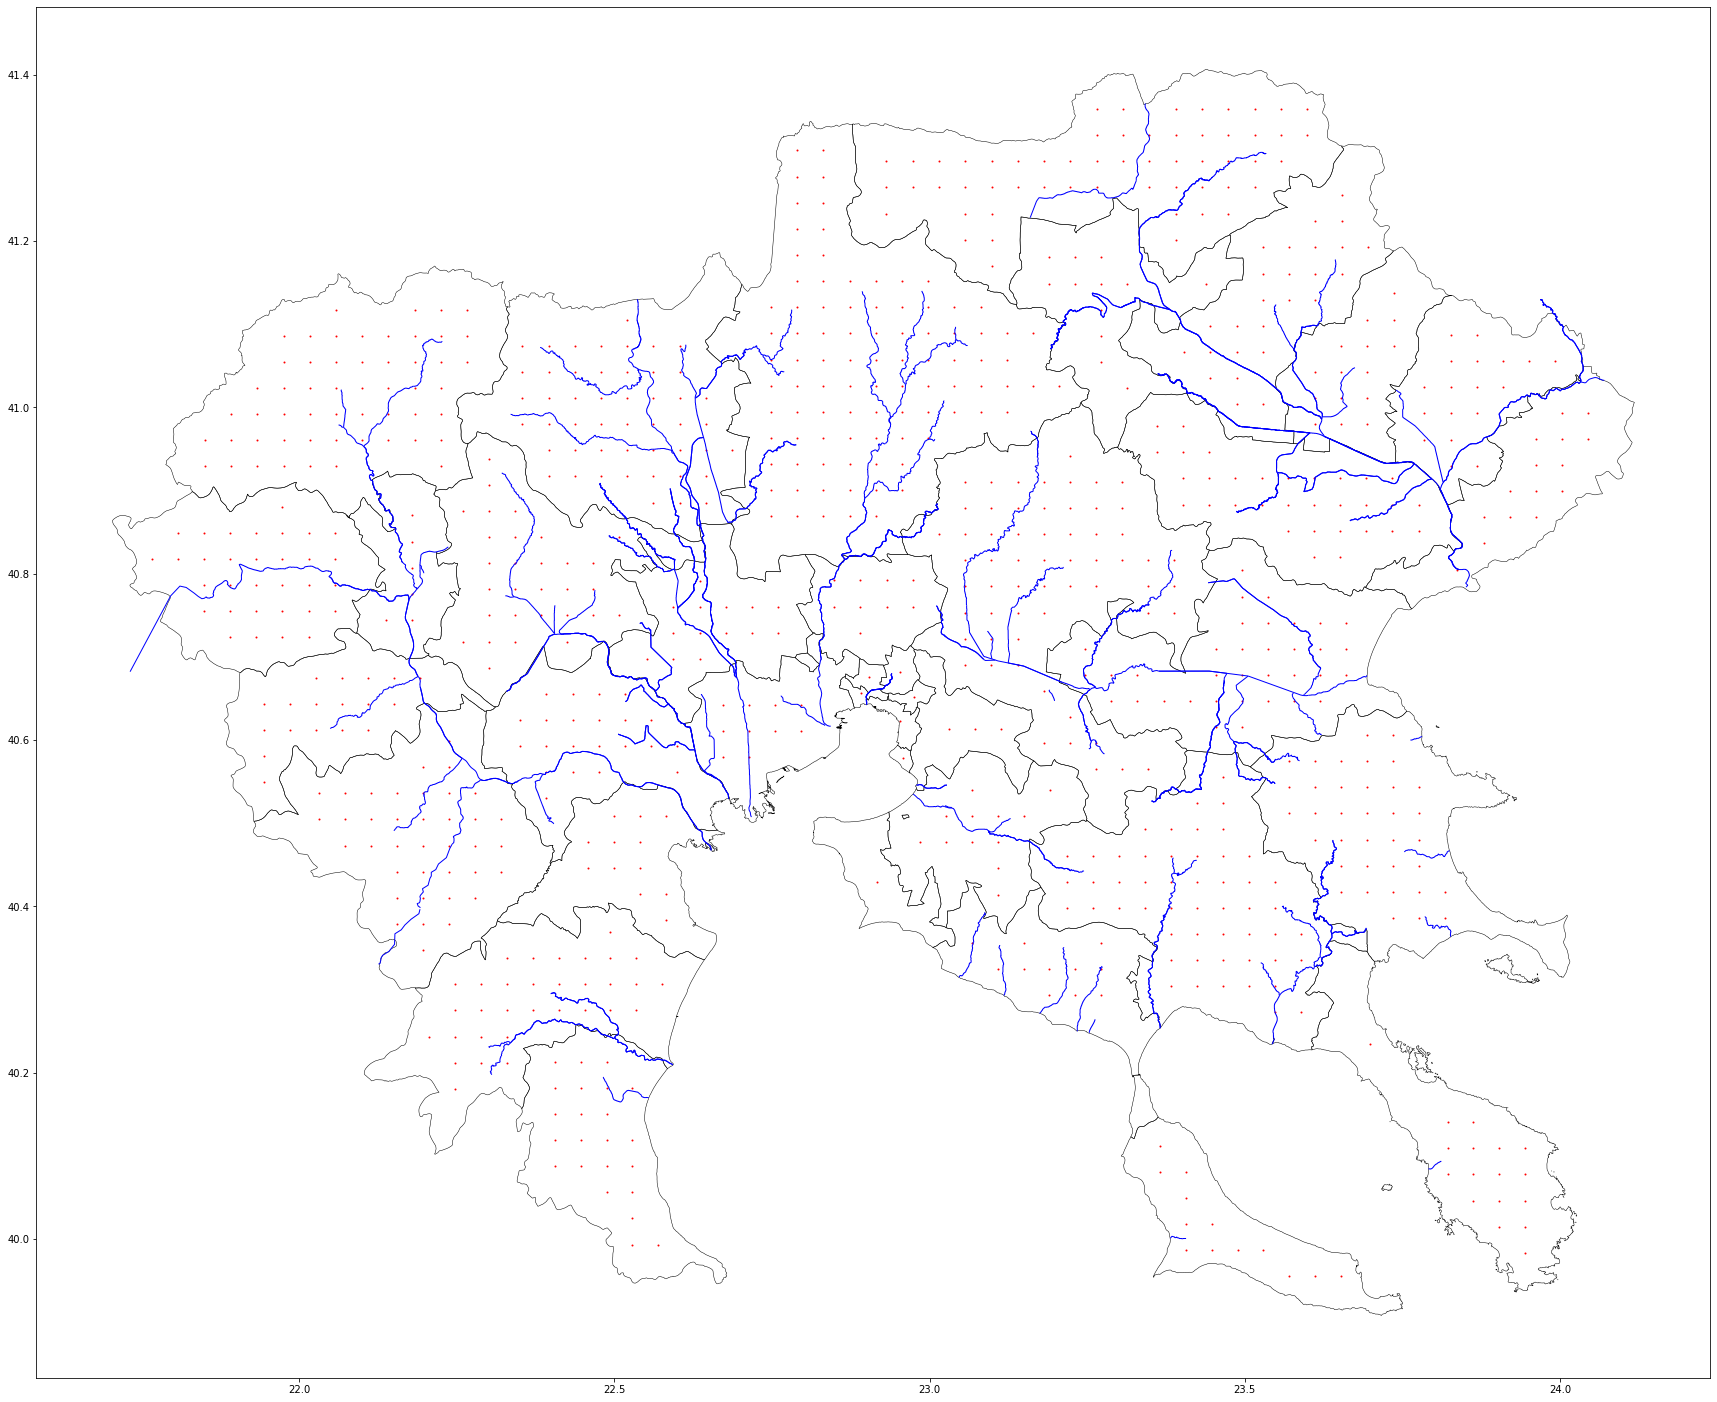

In [34]:
ax = nuts2_grid_points.plot(markersize=1, figsize=(30, 30), color='red')
nuts2_gdf.plot(facecolor="none", edgecolor='black', ax=ax, lw=0.5)
nuts2_rivers_gdf.plot(facecolor="none", edgecolor='blue', ax=ax, lw=1)

In [35]:
value_counts = nuts2_grid['lau1'].value_counts().sort_values()

In [36]:
arr = value_counts.values

In [37]:
arr_norm = np.ceil((15*(arr - np.min(arr) + 1 )/np.ptp(arr))).astype(int)

In [38]:
value_counts_target = pd.Series(data=arr_norm, index=value_counts.index)

In [39]:
value_counts_target

παυλου μελα               1
θερμαϊκου                 1
αμπελοκηπων μενεμενης     1
νεαπολης συκεων           1
καλαμαριας                1
κορδελιου ευοσμου         1
θεσσαλονικης              1
πυλαιας χορτιατη          1
σκυδρας                   1
ωραιοκαστρου              2
δελτα                     2
νεας προποντιδας          2
θερμης                    2
πυδνας κολινδρου          2
ηρακλειας                 2
κασσανδρας                3
χαλκηδονος                3
αμφιπολης                 3
εμμανουηλ παππα           3
σιθωνιας                  3
ναουσας                   3
νεας ζιχνης               3
αλεξανδρειας              4
διου ολυμπου              4
σερρων                    5
πελλας                    5
βισαλτιας                 6
εδεσσας                   6
κατερινης                 6
βολβης                    6
αριστοτελη                6
βεροιας                   7
παιονιας                  9
πολυγυρου                 9
αλμωπιας                  9
σιντικης            

In [40]:
idx = []
points = [] 

for index, value in value_counts_target.iteritems():
    if value == value_counts[index]:
        pass
    else: 
        idx.append(index)
        points.append(value_counts[index] - value)
        print(f'Index: {index} || Value: {value_counts[index]} || Target Value: {value}')

Index: πυλαιας χορτιατη || Value: 3 || Target Value: 1
Index: σκυδρας || Value: 6 || Target Value: 1
Index: ωραιοκαστρου || Value: 9 || Target Value: 2
Index: δελτα || Value: 10 || Target Value: 2
Index: νεας προποντιδας || Value: 11 || Target Value: 2
Index: θερμης || Value: 12 || Target Value: 2
Index: πυδνας κολινδρου || Value: 12 || Target Value: 2
Index: ηρακλειας || Value: 12 || Target Value: 2
Index: κασσανδρας || Value: 13 || Target Value: 3
Index: χαλκηδονος || Value: 14 || Target Value: 3
Index: αμφιπολης || Value: 15 || Target Value: 3
Index: εμμανουηλ παππα || Value: 15 || Target Value: 3
Index: σιθωνιας || Value: 17 || Target Value: 3
Index: ναουσας || Value: 18 || Target Value: 3
Index: νεας ζιχνης || Value: 18 || Target Value: 3
Index: αλεξανδρειας || Value: 22 || Target Value: 4
Index: διου ολυμπου || Value: 23 || Target Value: 4
Index: σερρων || Value: 26 || Target Value: 5
Index: πελλας || Value: 30 || Target Value: 5
Index: βισαλτιας || Value: 32 || Target Value: 6
I

In [41]:
to_remove = pd.Series(data=points, index=idx)

In [42]:
to_remove

πυλαιας χορτιατη     2
σκυδρας              5
ωραιοκαστρου         7
δελτα                8
νεας προποντιδας     9
θερμης              10
πυδνας κολινδρου    10
ηρακλειας           10
κασσανδρας          10
χαλκηδονος          11
αμφιπολης           12
εμμανουηλ παππα     12
σιθωνιας            14
ναουσας             15
νεας ζιχνης         15
αλεξανδρειας        18
διου ολυμπου        19
σερρων              21
πελλας              25
βισαλτιας           26
εδεσσας             26
κατερινης           26
βολβης              29
αριστοτελη          30
βεροιας             31
παιονιας            40
πολυγυρου           43
αλμωπιας            45
σιντικης            47
λαγκαδα             50
κιλκις              76
dtype: int64

In [43]:
# indicies_to_remove = []

# for municipality, points in to_remove.iteritems():
#     indicies = nuts2_grid.loc[nuts2_grid['lau1'] ==  municipality].index.tolist()
#     to_removed = random.sample(indicies, points)
#     for item in to_removed:
#         indicies_to_remove.append(item)

# nuts2_grid.drop(index = indicies_to_remove, axis = 1, inplace = True)
# nuts2_grid.reset_index(inplace = True, drop = True)

In [44]:
nuts2_grid_points = gpd.GeoDataFrame(nuts2_grid, geometry=gpd.points_from_xy(nuts2_grid.x, nuts2_grid.y))

<AxesSubplot:>

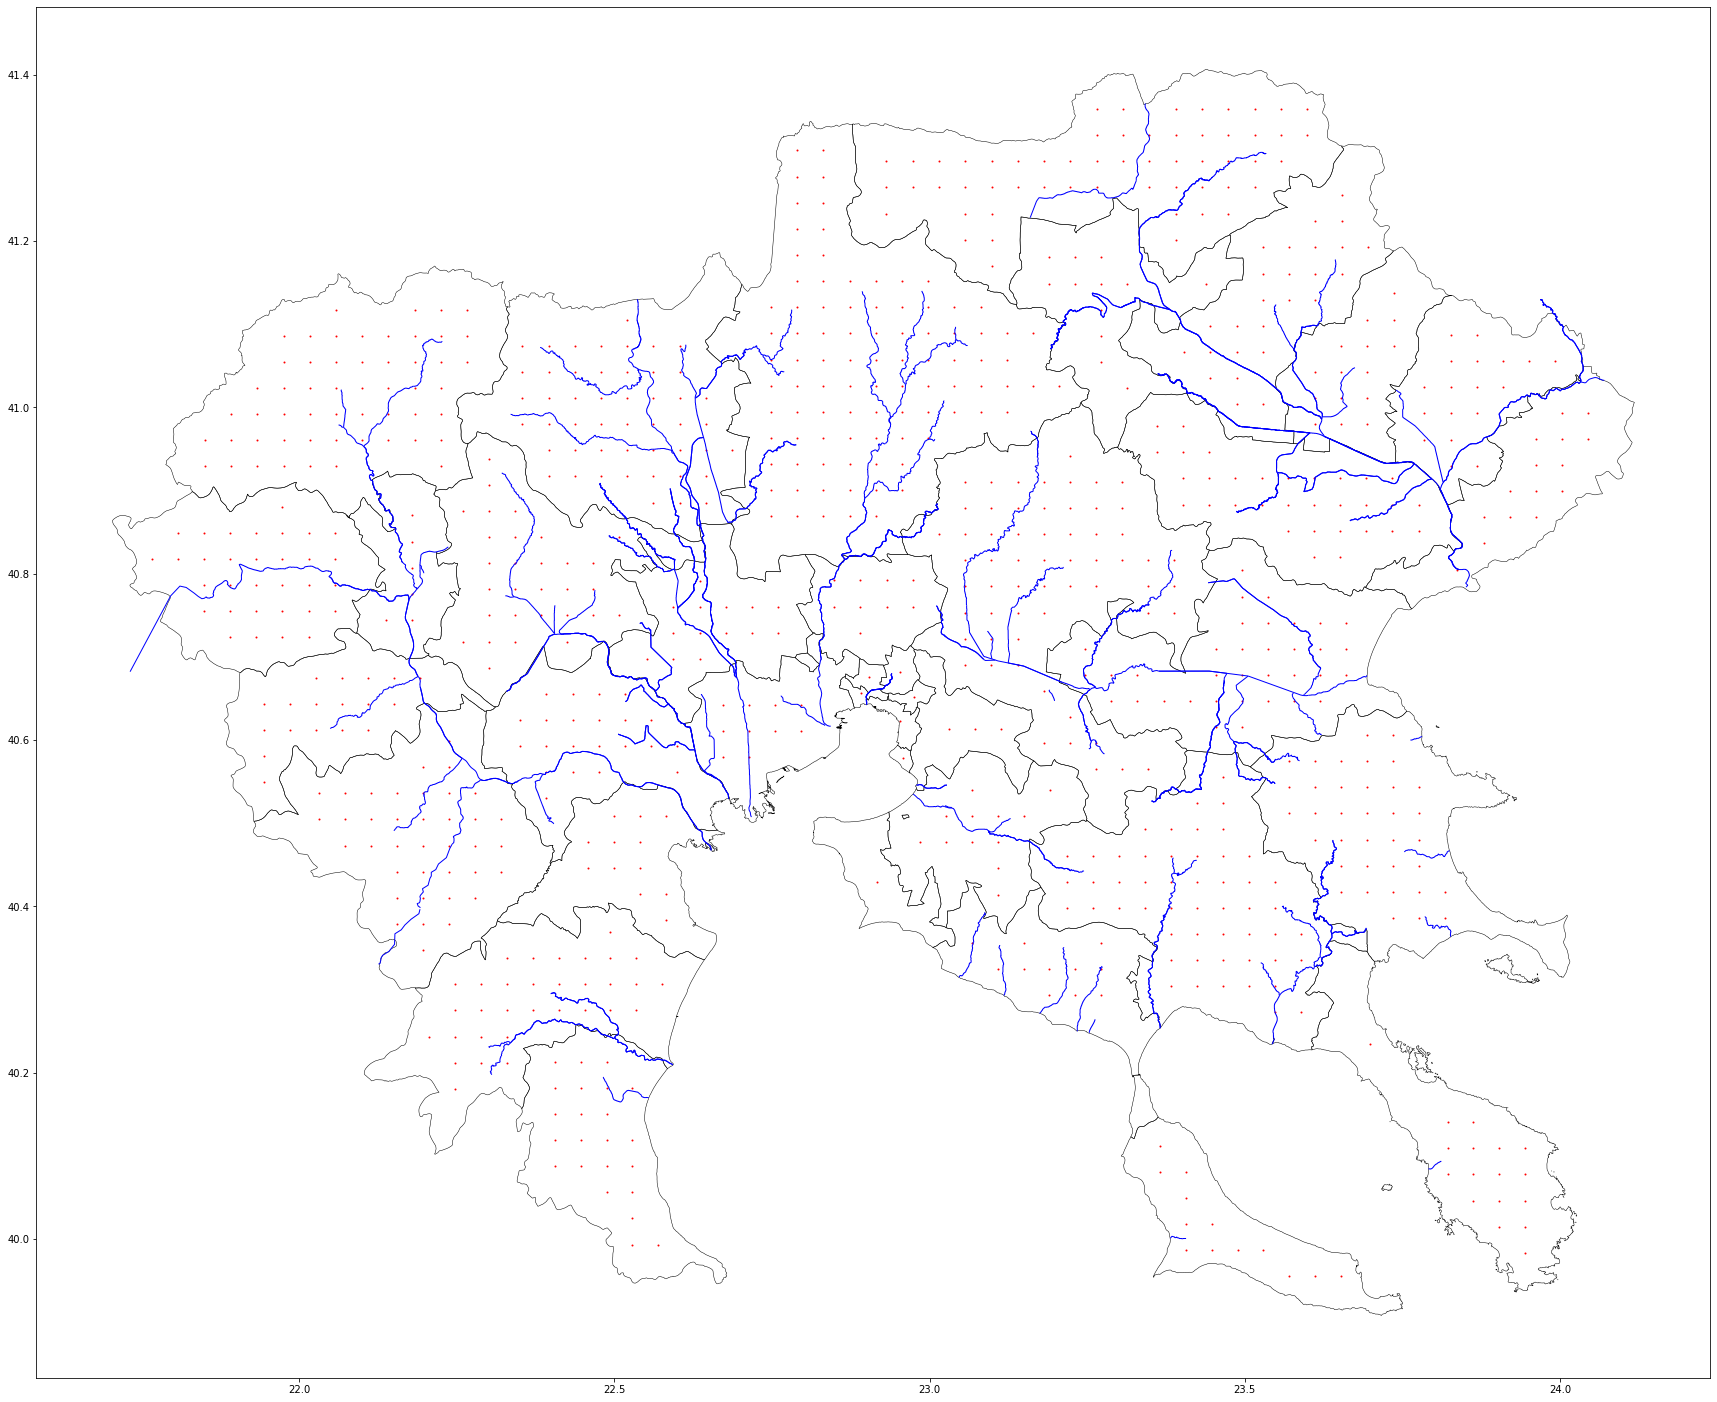

In [45]:
ax = nuts2_grid_points.plot(markersize=1, figsize=(30, 30), color='red')
nuts2_gdf.plot(facecolor="none", edgecolor='black', ax=ax, lw=0.5)
nuts2_rivers_gdf.plot(facecolor="none", edgecolor='blue', ax=ax, lw=1)

In [46]:
len(nuts2_grid['lau1'].unique())

38

In [47]:
nuts2_grid

,shape,lau1,x,y,nuts2,geometry
0,"POLYGON ((21.78711 40.80191, 21.78711 40.83335...",εδεσσας,21.76638,40.81763,κεντρικης μακεδονιας,POINT (21.76638 40.81763)
1,"POLYGON ((21.82857 40.80191, 21.82857 40.83335...",εδεσσας,21.80784,40.81763,κεντρικης μακεδονιας,POINT (21.80784 40.81763)
2,"POLYGON ((21.82857 40.83335, 21.82857 40.86479...",εδεσσας,21.80784,40.84907,κεντρικης μακεδονιας,POINT (21.80784 40.84907)
3,"POLYGON ((21.87003 40.73902, 21.87003 40.77047...",εδεσσας,21.84930,40.75474,κεντρικης μακεδονιας,POINT (21.84930 40.75474)
4,"POLYGON ((21.87003 40.77047, 21.87003 40.80191...",εδεσσας,21.84930,40.78619,κεντρικης μακεδονιας,POINT (21.84930 40.78619)
...,...,...,...,...,...,...
857,"POLYGON ((22.91314 40.65062, 22.91508 40.65002...",θεσσαλονικης,22.95369,40.62334,κεντρικης μακεδονιας,POINT (22.95369 40.62334)
858,"POLYGON ((22.97084 40.58797, 22.97046 40.58693...",καλαμαριας,22.95724,40.57876,κεντρικης μακεδονιας,POINT (22.95724 40.57876)
859,"POLYGON ((22.90533 40.69077, 22.90624 40.69074...",κορδελιου ευοσμου,22.90326,40.67609,κεντρικης μακεδονιας,POINT (22.90326 40.67609)
860,"POLYGON ((22.99249 40.66620, 22.99532 40.66530...",νεαπολης συκεων,22.97547,40.65206,κεντρικης μακεδονιας,POINT (22.97547 40.65206)


In [48]:
final_grid = nuts2_grid[['nuts2', 'lau1', 'x', 'y']].sort_values(by=['lau1'])

In [49]:
final_grid

,nuts2,lau1,x,y
32,κεντρικης μακεδονιας,αλεξανδρειας,22.35117,40.59303
34,κεντρικης μακεδονιας,αλεξανδρειας,22.39248,40.53014
35,κεντρικης μακεδονιας,αλεξανδρειας,22.39248,40.56159
36,κεντρικης μακεδονιας,αλεξανδρειας,22.39248,40.59303
37,κεντρικης μακεδονιας,αλεξανδρειας,22.39248,40.62447
...,...,...,...,...
850,κεντρικης μακεδονιας,ωραιοκαστρου,22.89038,40.76048
849,κεντρικης μακεδονιας,ωραιοκαστρου,22.89038,40.72903
848,κεντρικης μακεδονιας,ωραιοκαστρου,22.84892,40.79192
854,κεντρικης μακεδονιας,ωραιοκαστρου,22.97330,40.76048


In [50]:
final_grid.to_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Grid.csv', encoding=enc, index = False)